<a href="https://colab.research.google.com/github/YashitaaArya/Python-Practices/blob/main/FunctionTransformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [2]:
df=pd.read_csv("train.csv", usecols=['Age', 'Fare', 'Survived'])

In [3]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [4]:
# remove missing vals in age
df.isnull().sum()

,0
Survived,0
Age,177
Fare,0


In [5]:
df['Age'].fillna(df['Age'].mean(), inplace=True)

/tmp/ipykernel_2719/1698716155.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)


In [6]:
x=df.iloc[:,1:3]
y=df.iloc[:,0]

In [7]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

/tmp/ipykernel_2719/718055844.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Age'])


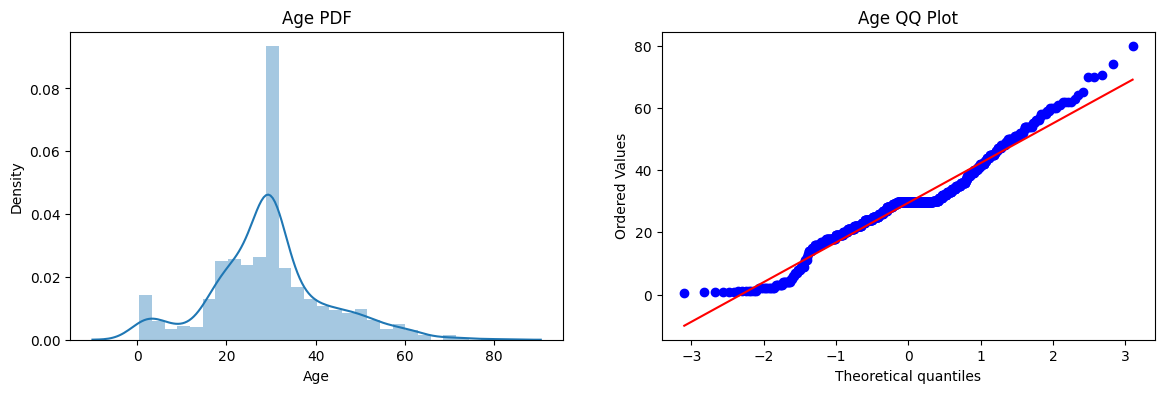

In [9]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(x_train['Age'])
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(x_train['Age'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.show()

/tmp/ipykernel_2719/3313795166.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Fare'])


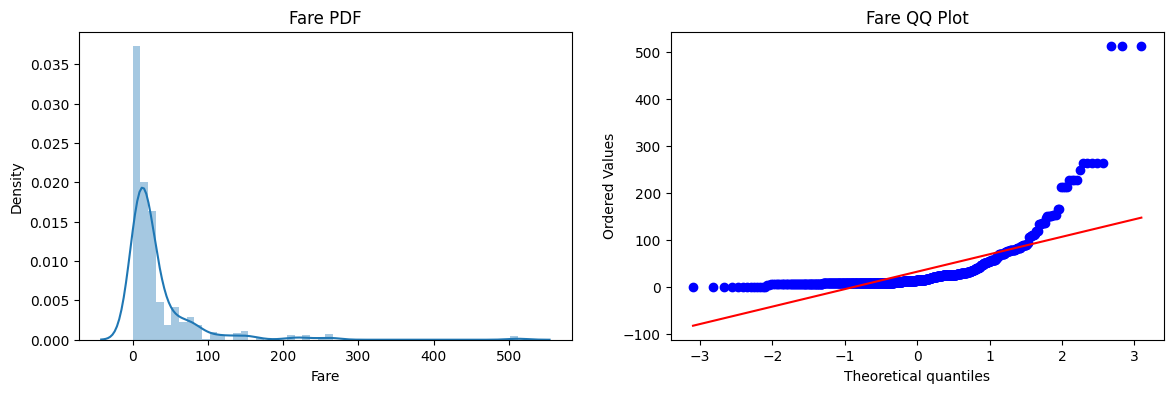

In [10]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(x_train['Fare'])
plt.title('Fare PDF')

plt.subplot(122)
stats.probplot(x_train['Fare'], dist="norm", plot=plt)
plt.title('Fare QQ Plot')

plt.show()

In [11]:
clf=LogisticRegression()
clf.fit(x_train, y_train)

LogisticRegression()

In [12]:
clf2=DecisionTreeClassifier()
clf2.fit(x_train, y_train)

DecisionTreeClassifier()

In [13]:
y_pred=clf.predict(x_test)
y_pred2=clf2.predict(x_test)

print("Accuracy LR ", accuracy_score(y_test, y_pred))
print("Accuracy DT ", accuracy_score(y_test, y_pred2))

Accuracy LR  0.6480446927374302
Accuracy DT  0.6703910614525139


In [14]:
trf=FunctionTransformer(func=np.log1p)

In [15]:
x_train_transformed=trf.fit_transform(x_train)
x_test_transformed=trf.transform(x_test)

In [16]:
clf=LogisticRegression()
clf.fit(x_train_transformed, y_train)
clf2=DecisionTreeClassifier()
clf2.fit(x_train_transformed, y_train)

y_pred=clf.predict(x_test_transformed)
y_pred2=clf2.predict(x_test_transformed)

print("Accuracy LR ", accuracy_score(y_test, y_pred))
print("Accuracy DT ", accuracy_score(y_test, y_pred2))


Accuracy LR  0.6815642458100558
Accuracy DT  0.6759776536312849


In [17]:
x_transformed=trf.fit_transform(x)
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

print("Accuracy LR ", np.mean(cross_val_score(clf, x_transformed, y, scoring='accuracy', cv=10)))
print("Accuracy DT ", np.mean(cross_val_score(clf2, x_transformed, y, scoring='accuracy', cv=10)))

Accuracy LR  0.678027465667915
Accuracy DT  0.6543695380774033


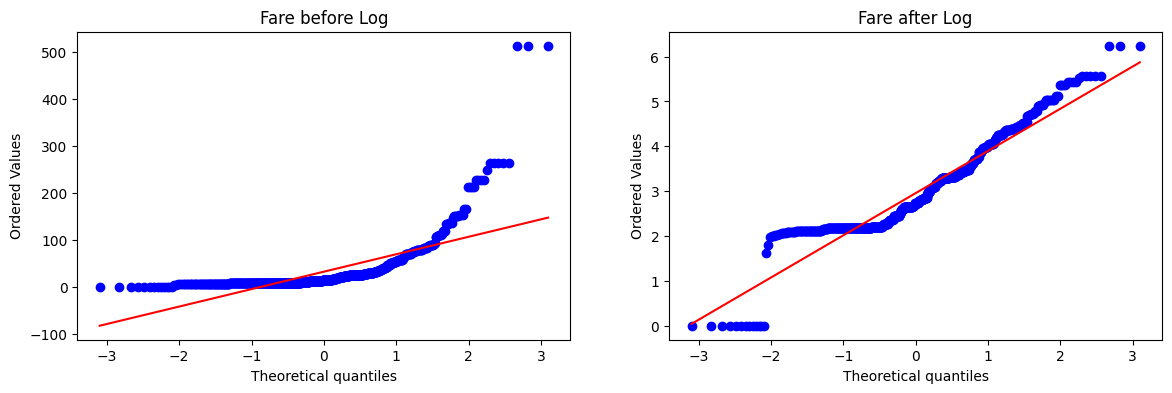

In [19]:
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(x_train['Fare'], dist="norm", plot=plt)
plt.title('Fare before Log')

plt.subplot(122)
stats.probplot(x_train_transformed['Fare'], dist="norm", plot=plt)
plt.title('Fare after Log')
plt.show()

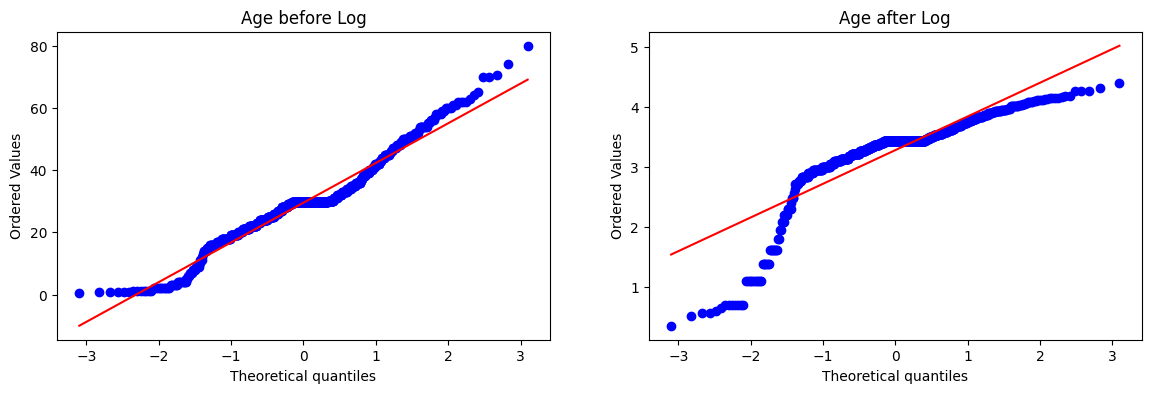

In [20]:
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(x_train['Age'], dist="norm", plot=plt)
plt.title('Age before Log')

plt.subplot(122)
stats.probplot(x_train_transformed['Age'], dist="norm", plot=plt)
plt.title('Age after Log')
plt.show()

In [21]:
trf2=ColumnTransformer([('log', FunctionTransformer(np.log1p), ['Fare'])], remainder='passthrough')
x_train_transformed2=trf2.fit_transform(x_train)
x_test_transformed2=trf2.transform(x_test)

In [22]:
clf=LogisticRegression()
clf.fit(x_train_transformed2, y_train)
clf2=DecisionTreeClassifier()
clf2.fit(x_train_transformed2, y_train)

y_pred=clf.predict(x_test_transformed2)
y_pred2=clf2.predict(x_test_transformed2)

print("Accuracy LR ", accuracy_score(y_test, y_pred))
print("Accuracy DT ", accuracy_score(y_test, y_pred2))

Accuracy LR  0.6703910614525139
Accuracy DT  0.6536312849162011


In [23]:
x_transformed2=trf2.fit_transform(x)
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

print("Accuracy LR ", np.mean(cross_val_score(clf, x_transformed2, y, scoring='accuracy', cv=10)))
print("Accuracy DT ", np.mean(cross_val_score(clf2, x_transformed2, y, scoring='accuracy', cv=10)))

Accuracy LR  0.6712609238451936
Accuracy DT  0.6577153558052433


In [24]:
def apply_transform(transform):
  x=df.iloc[:,1:3]
  y=df.iloc[:,0]
  trf=ColumnTransformer([('log', FunctionTransformer(transform), ['Fare'])], remainder='passthrough')
  x_transformed=trf.fit_transform(x)
  clf=LogisticRegression()
  print("Accuracy LR ", np.mean(cross_val_score(clf, x_transformed, y, scoring='accuracy', cv=10)))

  plt.figure(figsize=(14,4))
  plt.subplot(121)
  stats.probplot(x['Fare'], dist="norm", plot=plt)
  plt.title('Fare before Transform')

  plt.subplot(122)
  stats.probplot(x_transformed[:,0], dist="norm", plot=plt)
  plt.title('Fare after Transform')
  plt.show()

Accuracy LR  0.6589013732833957


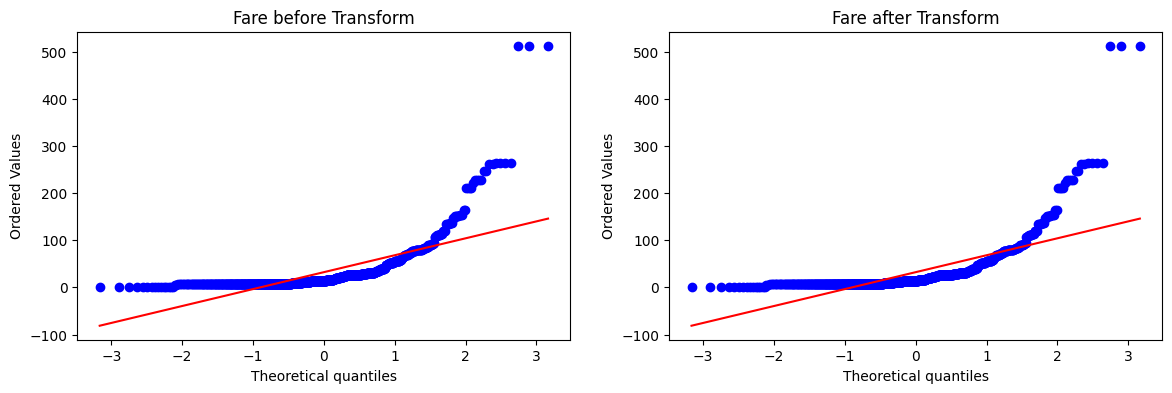

In [25]:
apply_transform(lambda x: x)

Accuracy LR  0.6431335830212235


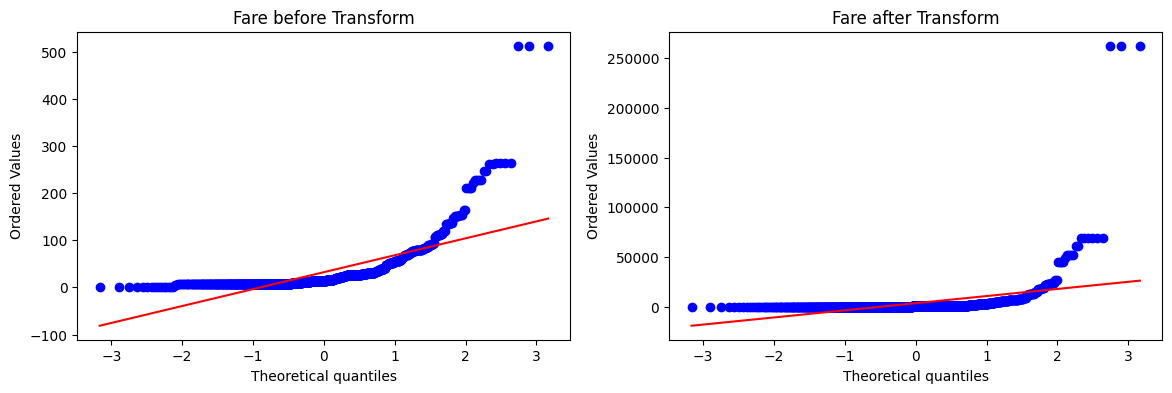

In [26]:
apply_transform(lambda x : x**2)

Accuracy LR  0.6589013732833957


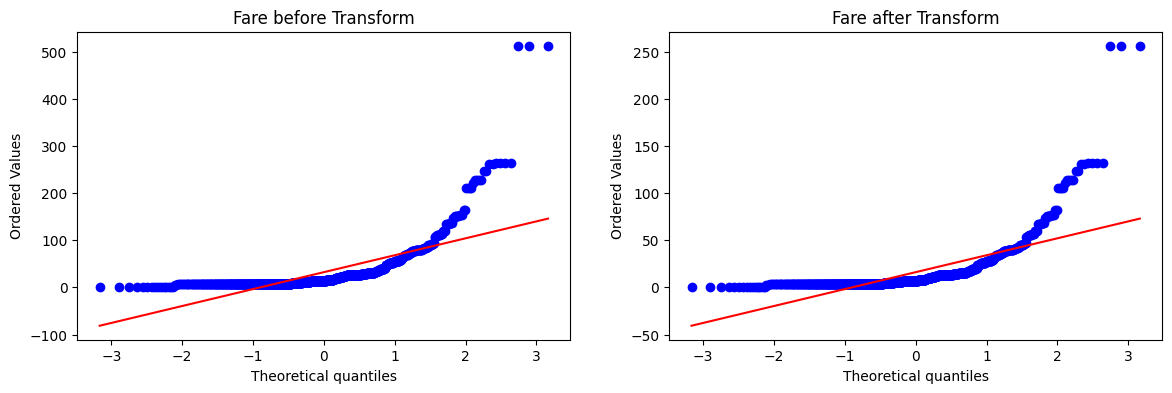

In [27]:
apply_transform(lambda x : x**1/2)

Accuracy LR  0.61729088639201


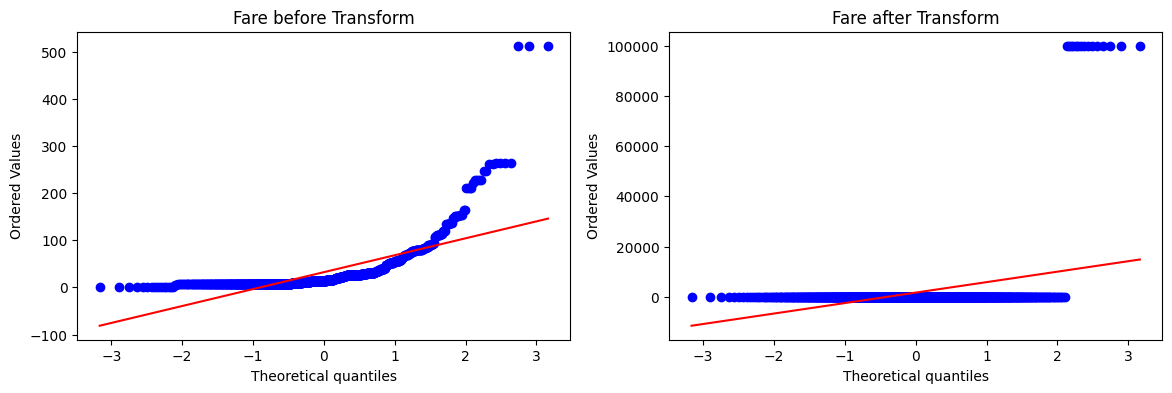

In [28]:
apply_transform(lambda x : 1/(x+0.00001))

Accuracy LR  0.6712609238451936


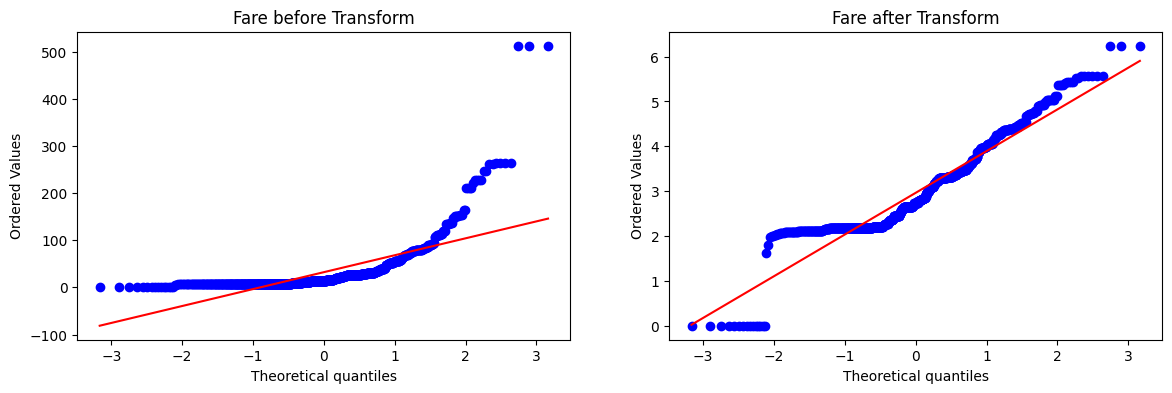

In [30]:
apply_transform(lambda x : np.log1p(x))

Accuracy LR  0.6611485642946316


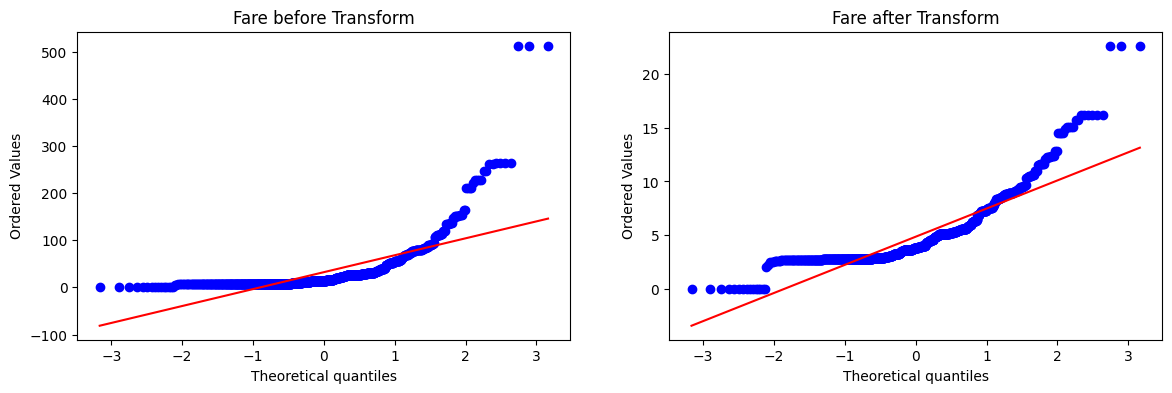

In [31]:
apply_transform(lambda x : np.sqrt(x))

Accuracy LR  0.6195131086142323


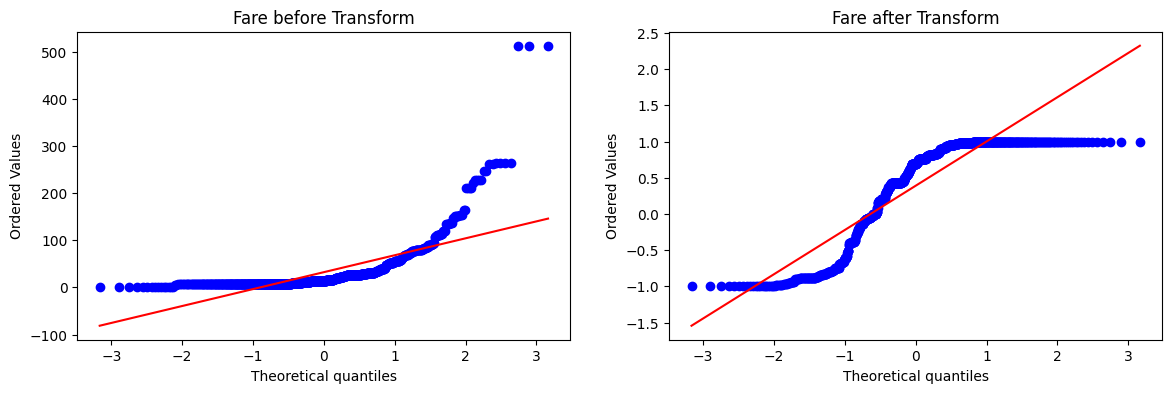

In [32]:
apply_transform(lambda x : np.sin(x))